<a href="https://colab.research.google.com/github/syedalijabir/math252-project/blob/main/fpdc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1 mount gDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Install R and Git tools in Colab

!apt-get update -qq
!apt-get install -y r-base git

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 60 not upgraded.


In [3]:
# 3. Clone repo into Colab

%cd /content
!git clone https://github.com/syedalijabir/math252-project.git
%cd /content/math252-project

/content
Cloning into 'math252-project'...
remote: Enumerating objects: 730, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 730 (delta 12), reused 39 (delta 5), pack-reused 677 (from 2)
Receiving objects: 100% (730/730), 2.24 GiB | 29.41 MiB/s, done.
Resolving deltas: 100% (132/132), done.
Updating files: 100% (327/327), done.
/content/math252-project


In [4]:
# 4. Enable R in Colab

%load_ext rpy2.ipython

# If errors, run this:
# !pip install rpy2
# %load_ext rpy2.ipython

In [5]:
# 5. Install required R packages
%%R
packages <- c(
  "readr",
  "dplyr",
  "ggplot2",
  "cluster",
  "factoextra",
  "clusterCrit",
  "FPDclustering",
  "clustrd"
)

installed <- rownames(installed.packages())
to_install <- setdiff(packages, installed)

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

lapply(packages, library, character.only = TRUE)

[[1]]
[1] "readr"     "tools"     "stats"     "graphics"  "grDevices" "utils"    
[7] "datasets"  "methods"   "base"     

[[2]]
 [1] "dplyr"     "readr"     "tools"     "stats"     "graphics"  "grDevices"
 [7] "utils"     "datasets"  "methods"   "base"     

[[3]]
 [1] "ggplot2"   "dplyr"     "readr"     "tools"     "stats"     "graphics" 
 [7] "grDevices" "utils"     "datasets"  "methods"   "base"     

[[4]]
 [1] "cluster"   "ggplot2"   "dplyr"     "readr"     "tools"     "stats"    
 [7] "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

[[5]]
 [1] "factoextra" "cluster"    "ggplot2"    "dplyr"      "readr"     
 [6] "tools"      "stats"      "graphics"   "grDevices"  "utils"     
[11] "datasets"   "methods"    "base"      

[[6]]
 [1] "clusterCrit" "factoextra"  "cluster"     "ggplot2"     "dplyr"      
 [6] "readr"       "tools"       "stats"       "graphics"    "grDevices"  
[11] "utils"       "datasets"    "methods"     "base"       

[[7]]
 [1] "FPDcluste

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘proxy’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘lazyeval’, ‘R.cache’, ‘e1071’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘numDeriv’, ‘corrplot’, ‘styler’, ‘classInt’, ‘labelled’, ‘patchwork’, ‘RcppEigen’, ‘modeltools’, ‘DEoptimR’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘prettyGraphs’, ‘combinat’, ‘questionr’, ‘ggstats’, ‘RSpectra’, ‘mclust’, ‘flexmix’, ‘prabclus’, ‘diptest’, ‘robustbase’, ‘kernlab’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘ThreeWay’, ‘mvtnorm’, ‘ExPosition’, ‘rootSolv

In [6]:
# 6. Copy or link repo files into Drive

%%R
base_repo <- "/content/math252-project"
drive_out <- "/content/drive/MyDrive/math252-project-colab-output"

dir.create(drive_out, recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_cache"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_plots"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_results"), recursive = TRUE, showWarnings = FALSE)

cat("Repo:", base_repo, "\n")
cat("Drive output:", drive_out, "\n")

Repo: /content/math252-project 
Drive output: /content/drive/MyDrive/math252-project-colab-output 


In [7]:
# 7. Upload or copy embeddings into the Colab repo if needed

#check they exist:

%%R
embedding_paths <- c(
  "/content/math252-project/output/embeddings/user_embeddings_64.csv",
  "/content/math252-project/output/embeddings/user_embeddings_128.csv",
  "/content/math252-project/output/embeddings/user_embeddings_256.csv"
)

print(file.exists(embedding_paths))
print(embedding_paths)

[1] TRUE TRUE TRUE
[1] "/content/math252-project/output/embeddings/user_embeddings_64.csv" 
[2] "/content/math252-project/output/embeddings/user_embeddings_128.csv"
[3] "/content/math252-project/output/embeddings/user_embeddings_256.csv"


In [8]:
import psutil, os, multiprocessing

ram_gb = psutil.virtual_memory().total / 1e9
cpu_count = multiprocessing.cpu_count()

print(f"RAM: {ram_gb:.1f} GB")
print(f"CPU cores visible: {cpu_count}")

if ram_gb < 20:
    print("Not using a high-RAM runtime")
else:
    print("Using a high-RAM runtime")

RAM: 13.6 GB
CPU cores visible: 2
Not using a high-RAM runtime



TuckerFactors for: user_embeddings_64.csv 
1 % of the process completed
12 % of the process completed
24 % of the process completed
36 % of the process completed
47 % of the process completed
59 % of the process completed
71 % of the process completed
82 % of the process completed
94 % of the process completed
          [,1]     [,2]     [,3]     [,4]     [,5]     [,6]     [,7]     [,8]
 [1,] 65.19652 65.19652 65.19652 65.19652 65.19652 65.19652 65.19652 65.19652
 [2,] 65.19652 65.96335 65.96335 65.96335 65.96335 65.96335 65.96335 65.96335
 [3,] 65.19652 65.96335 66.70848 66.70848 66.70848 66.70848 66.70848 66.70848
 [4,] 65.19652 65.96335 66.70848 67.43883 67.43883 67.43883 67.43883 67.43883
 [5,] 65.19652 65.96335 66.70848 67.43883 68.16241 68.16241 68.16241 68.16241
 [6,] 65.19652 65.96335 66.70848 67.43883 68.16241 68.87476 68.87476 68.87476
 [7,] 65.19652 65.96335 66.70848 67.43883 68.16241 68.87476 69.57741 69.57741
 [8,] 65.19652 65.96335 66.70848 67.43883 68.16241 68.87476 69.

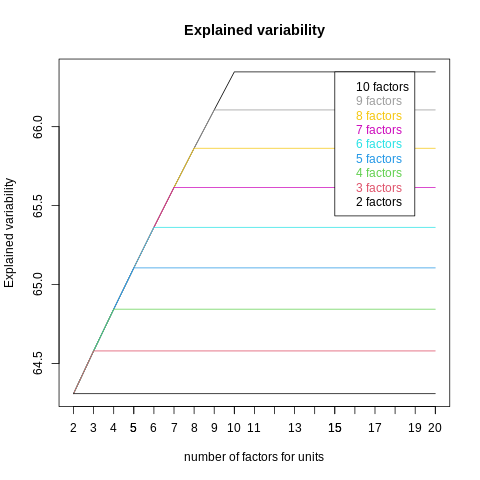

In [ ]:
# %%R
# library(readr)
# library(FPDclustering)

# base_repo <- "/content/math252-project"

# embedding_paths <- c(
#   file.path(base_repo, "output", "embeddings", "user_embeddings_64.csv"),
#   file.path(base_repo, "output", "embeddings", "user_embeddings_128.csv"),
#   file.path(base_repo, "output", "embeddings", "user_embeddings_256.csv")
# )

# for (embedding_path in embedding_paths) {
#   if (!file.exists(embedding_path)) {
#     cat("Missing file:", embedding_path, "\n")
#     next
#   }

#   cat("\n==============================\n")
#   cat("TuckerFactors for:", basename(embedding_path), "\n")
#   cat("==============================\n")

#   embeddings <- read_csv(embedding_path, show_col_types = FALSE)
#   x <- scale(as.matrix(embeddings[, -1]))

#   # Change 6 if want to inspect more candidate nf values
#   tf <- TuckerFactors(x, 7)

#   print(tf)
# }

In [ ]:
%%R
library(readr)
library(dplyr)
library(cluster)
library(clusterCrit)
library(FPDclustering)

set.seed(42)

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------
base_repo <- "/content/math252-project"
drive_out <- "/content/drive/MyDrive/math252-project-colab-output"

dir.create(file.path(drive_out, "output"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_cache"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_results"), recursive = TRUE, showWarnings = FALSE)

all_embedding_paths <- c(
  file.path(base_repo, "output", "embeddings", "user_embeddings_64.csv"),
  file.path(base_repo, "output", "embeddings", "user_embeddings_128.csv"),
  file.path(base_repo, "output", "embeddings", "user_embeddings_256.csv")
)

# --------------------------------------------------
# 2. Mode switch
# --------------------------------------------------
run_mode <- "full"   # change to "full" later

if (run_mode == "test") {
  embedding_paths <- embedding_paths[1]
  k_range <- 2:4
  nf_range <- 2:3
  fixed_nu <- 6
} else if (run_mode == "full") {
  k_range <- 2:8
  nf_range <- 2:5
  fixed_nu <- 6
} else {
  stop("run_mode must be 'test' or 'full'")
}

cat("Run mode:", run_mode, "\n")
cat("Embeddings:\n")
print(embedding_paths)
cat("k range:", paste(range(k_range), collapse = " to "), "\n")
cat("nf range:", paste(range(nf_range), collapse = " to "), "\n")
cat("fixed nu:", fixed_nu, "\n\n")
# --------------------------------------------------
# 3. Main FPDC loop
# --------------------------------------------------
all_results <- list()
overall_start <- Sys.time()

for (embedding_path in embedding_paths) {

  if (!file.exists(embedding_path)) {
    cat("Missing file:", embedding_path, "\n")
    next
  }

  embedding_start <- Sys.time()
  embedding_tag <- tools::file_path_sans_ext(basename(embedding_path))

  cat("---------------------------------------\n")
  cat("Processing:", embedding_tag, "\n")
  cat("---------------------------------------\n")

  full_cache_file <- file.path(
    drive_out, "output", "fpdc_cache",
    paste0("fpdc_full_result_", embedding_tag, ".rds")
  )

  # if (file.exists(full_cache_file)) {
  #   cat("Loading full cached result for:", embedding_tag, "\n")
  #   all_results[[embedding_tag]] <- readRDS(full_cache_file)
  #   next
  # }

  embeddings <- read_csv(embedding_path, show_col_types = FALSE)
  user_ids <- embeddings[[1]]
  embedding_matrix <- scale(as.matrix(embeddings[, -1]))

  dmat <- dist(embedding_matrix)

  results_grid <- expand.grid(k = k_range, nf = nf_range)
  results_grid$Silhouette <- NA_real_
  results_grid$CH <- NA_real_
  results_grid$ProbSilh <- NA_real_
  results_grid$runtime_sec <- NA_real_
  results_grid$status <- "ok"
  results_grid$notes <- NA_character_

  total_jobs <- nrow(results_grid)
  fpdc_models <- vector("list", total_jobs)

  for (i in seq_len(total_jobs)) {
    k_val <- results_grid$k[i]
    nf_val <- results_grid$nf[i]

    cat(sprintf("\n[%d/%d] %s | k=%d nf=%d\n",
                i, total_jobs, embedding_tag, k_val, nf_val))

    cache_file <- file.path(
        drive_out, "output", "fpdc_cache",
        paste0("fpdc_", embedding_tag, "_k", k_val, "_nf", nf_val, "_nu", fixed_nu, ".rds")
        )

    if (file.exists(cache_file)) {
      cat("Loading cached result\n")
      cached <- readRDS(cache_file)

      model <- cached$model
      avg_sil <- cached$Silhouette
      ch_val <- cached$CH
      prob_sil <- cached$ProbSilh

      results_grid$runtime_sec[i] <- cached$runtime_sec
      results_grid$status[i] <- cached$status
      results_grid$notes[i] <- cached$notes

    } else {
      cat("Running FPDC\n")
      t0 <- Sys.time()

      model <- tryCatch(
          FPDC(
              data = embedding_matrix,
              k = k_val,
              nf = nf_val,
              nu = fixed_nu
              ),
          error = function(e) {
              results_grid$status[i] <<- "error"
              results_grid$notes[i] <<- conditionMessage(e)
              NULL
              }
          )
      runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
      results_grid$runtime_sec[i] <- runtime_i

      if (is.null(model)) {
        cat("FAILED:", results_grid$notes[i], "\n")
        next
      }

      labels <- model$label

      sil <- silhouette(labels, dmat)
      avg_sil <- mean(sil[, 3])

      ch_val <- intCriteria(
        traj = embedding_matrix,
        part = as.integer(labels),
        crit = "Calinski_Harabasz"
      )$calinski_harabasz

      prob_sil <- Silh(model$probability)

      saveRDS(
        list(
          model = model,
          Silhouette = avg_sil,
          CH = ch_val,
          ProbSilh = prob_sil,
          runtime_sec = runtime_i,
          status = results_grid$status[i],
          notes = results_grid$notes[i],
          k = k_val,
          nf = nf_val,
          embedding_path = embedding_path
        ),
        cache_file
      )

      cat(sprintf("Done in %.1f sec | Sil=%.5f | CH=%.5f | ProbSilh=%.5f\n",
                  runtime_i, avg_sil, ch_val, prob_sil))
    }

    results_grid$Silhouette[i] <- avg_sil
    results_grid$CH[i] <- ch_val
    results_grid$ProbSilh[i] <- prob_sil
    fpdc_models[[i]] <- model
  }

  valid_idx <- which(!is.na(results_grid$Silhouette))
  if (length(valid_idx) == 0) {
    cat("No valid models for:", embedding_tag, "\n")
    next
  }

  best_index <- valid_idx[which.max(results_grid$Silhouette[valid_idx])]
  best_params <- results_grid[best_index, , drop = FALSE]

  best_k <- best_params$k
  best_nf <- best_params$nf
  best_fpdc <- fpdc_models[[best_index]]
  best_labels <- best_fpdc$label

  cluster_df <- data.frame(
    UserID = user_ids,
    Cluster = best_labels
  )

  cluster_sizes <- table(cluster_df$Cluster)
  runtime_total_sec <- as.numeric(difftime(Sys.time(), embedding_start, units = "secs"))

  tmp_notes <- unique(na.omit(results_grid$notes))
  notes_text <- if (length(tmp_notes) > 0) paste(tmp_notes, collapse = " | ") else NA_character_

  summary_row <- data.frame(
    method = "FPDC",
    embedding = embedding_tag,
    best_k = best_k,
    best_nf = best_nf,
    silhouette = best_params$Silhouette,
    CH = best_params$CH,
    prob_silh = best_params$ProbSilh,
    cluster_size_min = min(cluster_sizes),
    cluster_size_max = max(cluster_sizes),
    cluster_size_sd = sd(as.numeric(cluster_sizes)),
    runtime_total_sec = runtime_total_sec,
    notes = notes_text
  )

  res <- list(
    embedding_path = embedding_path,
    embedding_tag = embedding_tag,
    results_grid = results_grid,
    best_index = best_index,
    best_params = best_params,
    best_k = best_k,
    best_nf = best_nf,
    best_fpdc = best_fpdc,
    best_labels = best_labels,
    cluster_df = cluster_df,
    runtime_total_sec = runtime_total_sec,
    summary_row = summary_row
  )

  all_results[[embedding_tag]] <- res

  write.csv(
    cluster_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_clusters_", embedding_tag, "_k", best_k, "_nf", best_nf, ".csv")
    ),
    row.names = FALSE
  )

  write.csv(
    results_grid,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_tuning_results_", embedding_tag, ".csv")
    ),
    row.names = FALSE
  )

  saveRDS(
    best_fpdc,
    file = file.path(
      drive_out, "output", "fpdc_cache",
      paste0("best_fpdc_", embedding_tag, "_k", best_k, "_nf", best_nf, ".rds")
    )
  )

  saveRDS(
    res,
    file = full_cache_file
  )

  cat("\nFinished:", embedding_tag, "\n")
  cat("Best k:", best_k, "| Best number of factors:", best_nf, "\n")
  cat("Best silhouette:", best_params$Silhouette, "\n")
  cat("Embedding runtime:", round(runtime_total_sec, 1), "sec\n")
}

# --------------------------------------------------
# 4. Best overall summary
# --------------------------------------------------
if (length(all_results) > 0) {

  all_best <- lapply(all_results, function(res) {
    data.frame(
      embedding = res$embedding_tag,
      best_k = res$best_k,
      best_nf = res$best_nf,
      Silhouette = res$best_params$Silhouette,
      CH = res$best_params$CH,
      ProbSilh = res$best_params$ProbSilh
    )
  })

  all_best_df <- bind_rows(all_best)
  all_summary_df <- bind_rows(lapply(all_results, function(x) x$summary_row))

  best_overall_index <- with(all_best_df, order(-Silhouette, -CH))[1]
  best_overall <- all_best_df[best_overall_index, , drop = FALSE]
  best_name <- best_overall$embedding
  best_res <- all_results[[best_name]]

  write.csv(
    all_best_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      "fpdc_best_overall_summary.csv"
    ),
    row.names = FALSE
  )

  write.csv(
    all_summary_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      "fpdc_summary_table.csv"
    ),
    row.names = FALSE
  )

  write.csv(
    best_res$cluster_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_best_overall_clusters_", best_name,
             "_k", best_res$best_k, "_nf", best_res$best_nf, ".csv")
    ),
    row.names = FALSE
  )

  write.csv(
    best_res$results_grid,
    file = file.path(
      drive_out, "output", "fpdc_results",
      "fpdc_tuning_results_best_overall.csv"
    ),
    row.names = FALSE
  )

  cat("\n========================================\n")
  cat("BEST OVERALL RESULT\n")
  cat("========================================\n")
  print(best_overall)
}

cat("\nAll done.\n")
cat("Total runtime:",
    round(as.numeric(difftime(Sys.time(), overall_start, units = "mins")), 2),
    "minutes\n")
cat("Saved files in:\n", file.path(drive_out, "output", "fpdc_results"), "\n")

Run mode: full 
Embeddings:
[1] "/content/math252-project/output/embeddings/user_embeddings_64.csv" 
[2] "/content/math252-project/output/embeddings/user_embeddings_128.csv"
[3] "/content/math252-project/output/embeddings/user_embeddings_256.csv"
k range: 2 to 8 
nf range: 2 to 5 
fixed nu: 6 

---------------------------------------
Processing: user_embeddings_64 
---------------------------------------

[1/28] user_embeddings_64 | k=2 nf=2
Running FPDC


# RUN ALL FOR TIME COMPARISON

In [ ]:
%%R
library(readr)
library(dplyr)
library(cluster)
library(clusterCrit)
library(clustrd)
library(FPDclustering)
library(tidyr)

set.seed(42)

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------
base_repo <- "/content/math252-project"
drive_out <- "/content/drive/MyDrive/math252-project-colab-output"

dir.create(file.path(drive_out, "output"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "benchmark_cache"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "benchmark_results"), recursive = TRUE, showWarnings = FALSE)

all_embedding_paths <- c(
  # file.path(base_repo, "output", "embeddings", "user_embeddings_64.csv"),
  file.path(base_repo, "output", "embeddings", "user_embeddings_128.csv")
  #,
  #file.path(base_repo, "output", "embeddings", "user_embeddings_256.csv")
)

# --------------------------------------------------
# 2. Mode switch
# --------------------------------------------------
run_mode <- "full"   # change to "full" later

if (run_mode == "test") {
  embedding_paths <- all_embedding_paths[1]
  k_range <- 2:4
  nf_range <- 4:5   # only for RKM
} else if (run_mode == "full") {
  embedding_paths <- all_embedding_paths
  k_range <- 4:8
  nf_range <- 2:5
} else {
  stop("run_mode must be 'test' or 'full'")
}

cat("Run mode:", run_mode, "\n")
print(embedding_paths)
cat("k range:", paste(range(k_range), collapse = " to "), "\n")
cat("nf range (RKM only):", paste(range(nf_range), collapse = " to "), "\n\n")

# --------------------------------------------------
# 3. Helper functions
# --------------------------------------------------

safe_ch <- function(x, labels) {
  out <- tryCatch(
    intCriteria(
      traj = x,
      part = as.integer(labels),
      crit = "Calinski_Harabasz"
    )$calinski_harabasz,
    error = function(e) NA_real_
  )
  out
}

safe_sil <- function(labels, dmat) {
  out <- tryCatch(
    mean(silhouette(labels, dmat)[, 3]),
    error = function(e) NA_real_
  )
  out
}

# --------------------------------------------------
# 4. Main loop
# --------------------------------------------------
all_method_summaries <- list()
all_best_models <- list()

overall_start <- Sys.time()

for (embedding_path in embedding_paths) {

  if (!file.exists(embedding_path)) {
    cat("Missing file:", embedding_path, "\n")
    next
  }

  embedding_tag <- tools::file_path_sans_ext(basename(embedding_path))
  cat("\n========================================\n")
  cat("Processing embedding:", embedding_tag, "\n")
  cat("========================================\n")

  embeddings <- read_csv(embedding_path, show_col_types = FALSE)
  user_ids <- embeddings[[1]]
  x <- scale(as.matrix(embeddings[, -1]))
  dmat <- dist(x)

  # --------------------------------------
  # KMEANS
  # --------------------------------------
  kmeans_results <- list()

  for (k_val in k_range) {
    cache_file <- file.path(
      drive_out, "output", "benchmark_cache",
      paste0("kmeans_", embedding_tag, "_k", k_val, ".rds")
    )

    if (file.exists(cache_file)) {
      res <- readRDS(cache_file)
    } else {
      t0 <- Sys.time()

      model <- kmeans(
        x,
        centers = k_val,
        nstart = 25,
        iter.max = 100,
        algorithm = "MacQueen"
      )

      runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
      sil_val <- safe_sil(model$cluster, dmat)
      ch_val <- safe_ch(x, model$cluster)

      res <- list(
        Method = "KMeans",
        embedding = embedding_tag,
        k = k_val,
        nf = NA,
        runtime_sec = runtime_i,
        Silhouette = sil_val,
        CH = ch_val,
        ProbSilh = NA_real_,
        labels = model$cluster,
        model = model
      )

      saveRDS(res, cache_file)
    }

    kmeans_results[[length(kmeans_results) + 1]] <- res
    cat(sprintf("KMeans | %s | k=%d | time=%.1f | Sil=%.5f | CH=%.5f\n",
                embedding_tag, k_val, res$runtime_sec, res$Silhouette, res$CH))
  }

  kmeans_df <- bind_rows(lapply(kmeans_results, function(z) {
    data.frame(
      Method = z$Method,
      embedding = z$embedding,
      k = z$k,
      nf = z$nf,
      runtime_sec = z$runtime_sec,
      Silhouette = z$Silhouette,
      CH = z$CH,
      ProbSilh = z$ProbSilh
    )
  }))

  valid_km <- which(!is.na(kmeans_df$Silhouette))
  best_km_idx <- valid_km[order(-kmeans_df$Silhouette[valid_km], -kmeans_df$CH[valid_km])[1]]
  best_km <- kmeans_results[[best_km_idx]]

  # --------------------------------------
  # PD
  # --------------------------------------
  pd_results <- list()

  for (k_val in k_range) {
    cache_file <- file.path(
      drive_out, "output", "benchmark_cache",
      paste0("pd_", embedding_tag, "_k", k_val, ".rds")
    )

    if (file.exists(cache_file)) {
      res <- readRDS(cache_file)
    } else {
      t0 <- Sys.time()

      model <- tryCatch(
        PDC(x, k = k_val),
        error = function(e) NULL
      )

      runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

      if (is.null(model)) {
        res <- list(
          Method = "PD",
          embedding = embedding_tag,
          k = k_val,
          nf = NA,
          runtime_sec = runtime_i,
          Silhouette = NA_real_,
          CH = NA_real_,
          ProbSilh = NA_real_,
          labels = NULL,
          model = NULL
        )
      } else {
        labels <- model$label
        sil_val <- safe_sil(labels, dmat)
        ch_val <- safe_ch(x, labels)
        prob_val <- tryCatch(Silh(model$probability), error = function(e) NA_real_)

        res <- list(
          Method = "PD",
          embedding = embedding_tag,
          k = k_val,
          nf = NA,
          runtime_sec = runtime_i,
          Silhouette = sil_val,
          CH = ch_val,
          ProbSilh = prob_val,
          labels = labels,
          model = model
        )
      }

      saveRDS(res, cache_file)
    }

    pd_results[[length(pd_results) + 1]] <- res
    cat(sprintf("PD     | %s | k=%d | time=%.1f | Sil=%.5f | CH=%.5f | Prob=%.5f\n",
                embedding_tag, k_val, res$runtime_sec, res$Silhouette, res$CH, res$ProbSilh))
  }

  pd_df <- bind_rows(lapply(pd_results, function(z) {
    data.frame(
      Method = z$Method,
      embedding = z$embedding,
      k = z$k,
      nf = z$nf,
      runtime_sec = z$runtime_sec,
      Silhouette = z$Silhouette,
      CH = z$CH,
      ProbSilh = z$ProbSilh
    )
  }))

  valid_pd <- which(!is.na(pd_df$Silhouette))
  best_pd_idx <- valid_pd[order(-pd_df$Silhouette[valid_pd], -pd_df$CH[valid_pd])[1]]
  best_pd <- pd_results[[best_pd_idx]]

  # --------------------------------------
  # RKM
  # --------------------------------------
  rkm_results <- list()

  for (k_val in k_range) {
    for (nf_val in nf_range) {
      cache_file <- file.path(
        drive_out, "output", "benchmark_cache",
        paste0("rkm_", embedding_tag, "_k", k_val, "_nf", nf_val, ".rds")
      )

      if (file.exists(cache_file)) {
        res <- readRDS(cache_file)
      } else {
        t0 <- Sys.time()

        model <- tryCatch(
          cluspca(
            x,
            nclus = k_val,
            ndim = nf_val,
            method = "RKM",
            rotation = "varimax"
          ),
          error = function(e) NULL
        )

        runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

        if (is.null(model)) {
          res <- list(
            Method = "RKM",
            embedding = embedding_tag,
            k = k_val,
            nf = nf_val,
            runtime_sec = runtime_i,
            Silhouette = NA_real_,
            CH = NA_real_,
            ProbSilh = NA_real_,
            labels = NULL,
            model = NULL
          )
        } else {
          labels <- model$cluster
          sil_val <- safe_sil(labels, dmat)
          ch_val <- safe_ch(x, labels)

          res <- list(
            Method = "RKM",
            embedding = embedding_tag,
            k = k_val,
            nf = nf_val,
            runtime_sec = runtime_i,
            Silhouette = sil_val,
            CH = ch_val,
            ProbSilh = NA_real_,
            labels = labels,
            model = model
          )
        }

        saveRDS(res, cache_file)
      }

      rkm_results[[length(rkm_results) + 1]] <- res
      cat(sprintf("RKM    | %s | k=%d nf=%d | time=%.1f | Sil=%.5f | CH=%.5f\n",
                  embedding_tag, k_val, nf_val, res$runtime_sec, res$Silhouette, res$CH))
    }
  }

  rkm_df <- bind_rows(lapply(rkm_results, function(z) {
    data.frame(
      Method = z$Method,
      embedding = z$embedding,
      k = z$k,
      nf = z$nf,
      runtime_sec = z$runtime_sec,
      Silhouette = z$Silhouette,
      CH = z$CH,
      ProbSilh = z$ProbSilh
    )
  }))

  valid_rkm <- which(!is.na(rkm_df$Silhouette))
  best_rkm_idx <- valid_rkm[order(-rkm_df$Silhouette[valid_rkm], -rkm_df$CH[valid_rkm])[1]]
  best_rkm <- rkm_results[[best_rkm_idx]]

  # --------------------------------------
  # Save per-embedding combined results
  # --------------------------------------
  combined_df <- bind_rows(kmeans_df, pd_df, rkm_df)

  write.csv(
    combined_df,
    file = file.path(
      drive_out, "output", "benchmark_results",
      paste0("benchmark_results_", embedding_tag, ".csv")
    ),
    row.names = FALSE
  )

  best_df <- bind_rows(
    data.frame(
      Method = "KMeans",
      embedding = embedding_tag,
      k = best_km$k,
      nf = best_km$nf,
      runtime_sec = best_km$runtime_sec,
      Silhouette = best_km$Silhouette,
      CH = best_km$CH,
      ProbSilh = best_km$ProbSilh
    ),
    data.frame(
      Method = "PD",
      embedding = embedding_tag,
      k = best_pd$k,
      nf = best_pd$nf,
      runtime_sec = best_pd$runtime_sec,
      Silhouette = best_pd$Silhouette,
      CH = best_pd$CH,
      ProbSilh = best_pd$ProbSilh
    ),
    data.frame(
      Method = "RKM",
      embedding = embedding_tag,
      k = best_rkm$k,
      nf = best_rkm$nf,
      runtime_sec = best_rkm$runtime_sec,
      Silhouette = best_rkm$Silhouette,
      CH = best_rkm$CH,
      ProbSilh = best_rkm$ProbSilh
    )
  )

  all_method_summaries[[embedding_tag]] <- best_df
  all_best_models[[paste0(embedding_tag, "_KMeans")]] <- best_km
  all_best_models[[paste0(embedding_tag, "_PD")]] <- best_pd
  all_best_models[[paste0(embedding_tag, "_RKM")]] <- best_rkm
}

# --------------------------------------------------
# 5. Save final summary table
# --------------------------------------------------
summary_df <- bind_rows(all_method_summaries)

write.csv(
  summary_df,
  file = file.path(
    drive_out, "output", "benchmark_results",
    "benchmark_best_models_summary.csv"
  ),
  row.names = FALSE
)

cat("\n========================================\n")
cat("FINAL BEST-MODEL SUMMARY\n")
cat("========================================\n")
print(summary_df)

cat("\nAll done.\n")
cat("Total runtime:",
    round(as.numeric(difftime(Sys.time(), overall_start, units = "mins")), 2),
    "minutes\n")
cat("Saved files in:\n", file.path(drive_out, "output", "benchmark_results"), "\n")

Run mode: full 
[1] "/content/math252-project/output/embeddings/user_embeddings_128.csv"
k range: 4 to 8 
nf range (RKM only): 2 to 5 


Processing embedding: user_embeddings_128 
KMeans | user_embeddings_128 | k=4 | time=1.9 | Sil=0.13021 | CH=91.12681
KMeans | user_embeddings_128 | k=5 | time=3.1 | Sil=-0.01418 | CH=78.82084
KMeans | user_embeddings_128 | k=6 | time=3.6 | Sil=-0.01679 | CH=70.87545
KMeans | user_embeddings_128 | k=7 | time=3.9 | Sil=0.02695 | CH=62.70341
KMeans | user_embeddings_128 | k=8 | time=4.8 | Sil=-0.04632 | CH=58.62617
PD     | user_embeddings_128 | k=4 | time=0.5 | Sil=-0.00776 | CH=1.05943 | Prob=0.02831
PD     | user_embeddings_128 | k=5 | time=0.6 | Sil=-0.00345 | CH=1.00377 | Prob=0.02330
PD     | user_embeddings_128 | k=6 | time=0.7 | Sil=-0.01834 | CH=1.16252 | Prob=0.01780
PD     | user_embeddings_128 | k=7 | time=0.7 | Sil=-0.01266 | CH=1.00925 | Prob=0.01786
PD     | user_embeddings_128 | k=8 | time=0.8 | Sil=-0.03331 | CH=1.12063 | Prob=0.01353
RK

Exception ignored from cffi callback <function _processevents at 0x788620320400>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 
Exception ignored from cffi callback <function _processevents at 0x788620320400>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 


# RUN FPDC FOR NU=6

In [ ]:
%%R
library(readr)
library(dplyr)
library(cluster)
library(clusterCrit)
library(FPDclustering)

set.seed(42)

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------
base_repo <- "/content/math252-project"
drive_out <- "/content/drive/MyDrive/math252-project-colab-output"

dir.create(file.path(drive_out, "output"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_cache"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "fpdc_results"), recursive = TRUE, showWarnings = FALSE)

all_embedding_paths <- c(
  file.path(base_repo, "output", "embeddings", "user_embeddings_64.csv"),
  file.path(base_repo, "output", "embeddings", "user_embeddings_128.csv"),
  file.path(base_repo, "output", "embeddings", "user_embeddings_256.csv")
)

# --------------------------------------------------
# 2. Mode switch
# --------------------------------------------------
run_mode <- "full"

if (run_mode == "test") {
  embedding_paths <- all_embedding_paths[1]
  k_range <- 2:4
  nf_range <- 2:3
} else if (run_mode == "full") {
  embedding_paths <- all_embedding_paths
  k_range <- 2:8
  nf_range <- 2:5
} else {
  stop("run_mode must be 'test' or 'full'")
}

fixed_nu <- 6

cat("Run mode:", run_mode, "\n")
cat("Embeddings:\n")
print(embedding_paths)
cat("k range:", paste(range(k_range), collapse = " to "), "\n")
cat("nf range:", paste(range(nf_range), collapse = " to "), "\n")
cat("fixed nu:", fixed_nu, "\n\n")

In [ ]:
%%R
all_results <- list()
overall_start <- Sys.time()

for (embedding_path in embedding_paths) {

  if (!file.exists(embedding_path)) {
    cat("Missing file:", embedding_path, "\n")
    next
  }

  embedding_start <- Sys.time()
  embedding_tag <- tools::file_path_sans_ext(basename(embedding_path))

  cat("---------------------------------------\n")
  cat("Processing:", embedding_tag, "| nu =", fixed_nu, "\n")
  cat("---------------------------------------\n")

  full_cache_file <- file.path(
    drive_out, "output", "fpdc_cache",
    paste0("fpdc_full_result_", embedding_tag, "_nu", fixed_nu, ".rds")
  )

  if (file.exists(full_cache_file)) {
    cat("Loading full cached result for:", embedding_tag, "nu =", fixed_nu, "\n")
    all_results[[embedding_tag]] <- readRDS(full_cache_file)
    next
  }

  embeddings <- read_csv(embedding_path, show_col_types = FALSE)
  user_ids <- embeddings[[1]]
  embedding_matrix <- scale(as.matrix(embeddings[, -1]))

  dmat <- dist(embedding_matrix)

  results_grid <- expand.grid(k = k_range, nf = nf_range)
  results_grid$nu <- fixed_nu
  results_grid$Silhouette <- NA_real_
  results_grid$CH <- NA_real_
  results_grid$ProbSilh <- NA_real_
  results_grid$runtime_sec <- NA_real_
  results_grid$status <- "ok"
  results_grid$notes <- NA_character_

  total_jobs <- nrow(results_grid)
  fpdc_models <- vector("list", total_jobs)

  for (i in seq_len(total_jobs)) {
    k_val <- results_grid$k[i]
    nf_val <- results_grid$nf[i]

    cat(sprintf("\n[%d/%d] %s | k=%d nf=%d nu=%d\n",
                i, total_jobs, embedding_tag, k_val, nf_val, fixed_nu))

    cache_file <- file.path(
      drive_out, "output", "fpdc_cache",
      paste0("fpdc_", embedding_tag, "_k", k_val, "_nf", nf_val, "_nu", fixed_nu, ".rds")
    )

    if (file.exists(cache_file)) {
      cat("Loading cached result\n")
      cached <- readRDS(cache_file)

      model <- cached$model
      avg_sil <- cached$Silhouette
      ch_val <- cached$CH
      prob_sil <- cached$ProbSilh

      results_grid$runtime_sec[i] <- cached$runtime_sec
      results_grid$status[i] <- cached$status
      results_grid$notes[i] <- cached$notes

    } else {
      cat("Running FPDC\n")
      t0 <- Sys.time()

      model <- tryCatch(
        FPDC(
          data = embedding_matrix,
          k = k_val,
          nf = nf_val,
          nu = fixed_nu
        ),
        error = function(e) {
          results_grid$status[i] <<- "error"
          results_grid$notes[i] <<- conditionMessage(e)
          NULL
        }
      )

      runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
      results_grid$runtime_sec[i] <- runtime_i

      if (is.null(model)) {
        cat("FAILED:", results_grid$notes[i], "\n")
        next
      }

      labels <- model$label
      sil <- silhouette(labels, dmat)
      avg_sil <- mean(sil[, 3])

      ch_val <- intCriteria(
        traj = embedding_matrix,
        part = as.integer(labels),
        crit = "Calinski_Harabasz"
      )$calinski_harabasz

      prob_sil <- Silh(model$probability)

      saveRDS(
        list(
          model = model,
          Silhouette = avg_sil,
          CH = ch_val,
          ProbSilh = prob_sil,
          runtime_sec = runtime_i,
          status = results_grid$status[i],
          notes = results_grid$notes[i],
          k = k_val,
          nf = nf_val,
          nu = fixed_nu,
          embedding_path = embedding_path
        ),
        cache_file
      )

      cat(sprintf("Done in %.1f sec | Sil=%.5f | CH=%.5f | ProbSilh=%.5f\n",
                  runtime_i, avg_sil, ch_val, prob_sil))
    }

    results_grid$Silhouette[i] <- avg_sil
    results_grid$CH[i] <- ch_val
    results_grid$ProbSilh[i] <- prob_sil
    fpdc_models[[i]] <- model
  }

  valid_idx <- which(!is.na(results_grid$Silhouette))
  if (length(valid_idx) == 0) {
    cat("No valid models for:", embedding_tag, "\n")
    next
  }

  best_index <- valid_idx[which.max(results_grid$Silhouette[valid_idx])]
  best_params <- results_grid[best_index, , drop = FALSE]

  best_k <- best_params$k
  best_nf <- best_params$nf
  best_fpdc <- fpdc_models[[best_index]]
  best_labels <- best_fpdc$label

  cluster_df <- data.frame(
    UserID = user_ids,
    Cluster = best_labels
  )

  cluster_sizes <- table(cluster_df$Cluster)
  runtime_total_sec <- as.numeric(difftime(Sys.time(), embedding_start, units = "secs"))

  tmp_notes <- unique(na.omit(results_grid$notes))
  notes_text <- if (length(tmp_notes) > 0) paste(tmp_notes, collapse = " | ") else NA_character_

  summary_row <- data.frame(
    method = "FPDC",
    embedding = embedding_tag,
    best_k = best_k,
    best_nf = best_nf,
    nu = fixed_nu,
    silhouette = best_params$Silhouette,
    CH = best_params$CH,
    prob_silh = best_params$ProbSilh,
    cluster_size_min = min(cluster_sizes),
    cluster_size_max = max(cluster_sizes),
    cluster_size_sd = sd(as.numeric(cluster_sizes)),
    runtime_total_sec = runtime_total_sec,
    notes = notes_text
  )

  res <- list(
    embedding_path = embedding_path,
    embedding_tag = embedding_tag,
    results_grid = results_grid,
    best_index = best_index,
    best_params = best_params,
    best_k = best_k,
    best_nf = best_nf,
    best_fpdc = best_fpdc,
    best_labels = best_labels,
    cluster_df = cluster_df,
    runtime_total_sec = runtime_total_sec,
    summary_row = summary_row
  )

  all_results[[embedding_tag]] <- res

  write.csv(
    cluster_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_clusters_", embedding_tag, "_k", best_k, "_nf", best_nf, "_nu", fixed_nu, ".csv")
    ),
    row.names = FALSE
  )

  write.csv(
    results_grid,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_tuning_results_", embedding_tag, "_nu", fixed_nu, ".csv")
    ),
    row.names = FALSE
  )

  saveRDS(
    best_fpdc,
    file = file.path(
      drive_out, "output", "fpdc_cache",
      paste0("best_fpdc_", embedding_tag, "_k", best_k, "_nf", best_nf, "_nu", fixed_nu, ".rds")
    )
  )

  saveRDS(
    res,
    file = full_cache_file
  )

  cat("\nFinished:", embedding_tag, "\n")
  cat("Best k:", best_k, "| Best nf:", best_nf, "| nu:", fixed_nu, "\n")
  cat("Best silhouette:", best_params$Silhouette, "\n")
  cat("Embedding runtime:", round(runtime_total_sec, 1), "sec\n")
}

In [ ]:
%%R
if (length(all_results) > 0) {

  all_best <- lapply(all_results, function(res) {
    data.frame(
      embedding = res$embedding_tag,
      best_k = res$best_k,
      best_nf = res$best_nf,
      nu = fixed_nu,
      Silhouette = res$best_params$Silhouette,
      CH = res$best_params$CH,
      ProbSilh = res$best_params$ProbSilh
    )
  })

  all_best_df <- bind_rows(all_best)
  all_summary_df <- bind_rows(lapply(all_results, function(x) x$summary_row))

  best_overall_index <- with(all_best_df, order(-Silhouette, -CH))[1]
  best_overall <- all_best_df[best_overall_index, , drop = FALSE]
  best_name <- best_overall$embedding
  best_res <- all_results[[best_name]]

  write.csv(
    all_best_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_best_overall_summary_nu", fixed_nu, ".csv")
    ),
    row.names = FALSE
  )

  write.csv(
    all_summary_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_summary_table_nu", fixed_nu, ".csv")
    ),
    row.names = FALSE
  )

  write.csv(
    best_res$cluster_df,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_best_overall_clusters_", best_name,
             "_k", best_res$best_k, "_nf", best_res$best_nf, "_nu", fixed_nu, ".csv")
    ),
    row.names = FALSE
  )

  write.csv(
    best_res$results_grid,
    file = file.path(
      drive_out, "output", "fpdc_results",
      paste0("fpdc_tuning_results_best_overall_nu", fixed_nu, ".csv")
    ),
    row.names = FALSE
  )

  cat("\n========================================\n")
  cat("BEST OVERALL RESULT\n")
  cat("========================================\n")
  print(best_overall)
}

cat("\nAll done.\n")
cat("Total runtime:",
    round(as.numeric(difftime(Sys.time(), overall_start, units = "mins")), 2),
    "minutes\n")
cat("Saved files in:\n", file.path(drive_out, "output", "fpdc_results"), "\n")